In [3]:
import pandas as pd 
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df =  pd.read_csv("customer_behavior.csv")

In [5]:
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [31]:
#What is the average, median, and mode of PurchaseAmount?

mean_purchase = df['PurchaseAmount'].mean()
median_purchase = df['PurchaseAmount'].median()
mode_purchase = df['PurchaseAmount'].mode()[0]

{
    "Mean": mean_purchase,
    "Median": median_purchase,
    "Mode": mode_purchase
}

{'Mean': np.float64(1003.9506701030928),
 'Median': 998.0799999999999,
 'Mode': np.float64(0.0)}

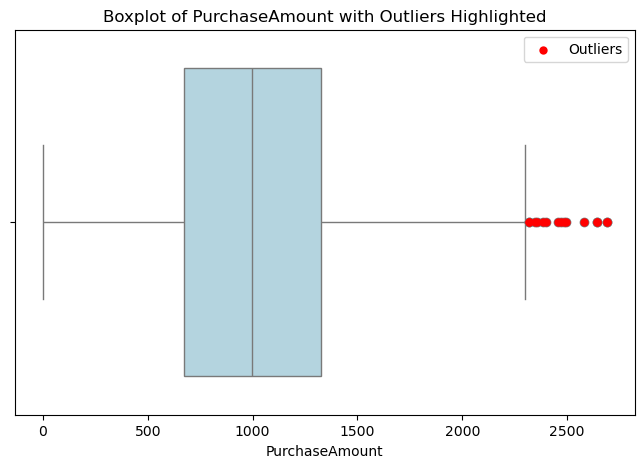

In [32]:
#Are there any outliers in the PurchaseAmount data?


Q1, Q3 = df['PurchaseAmount'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5*IQR, Q3 + 1.5*IQR

outliers = df[(df['PurchaseAmount'] < lower_bound) | (df['PurchaseAmount'] > upper_bound)]

plt.figure(figsize=(8,5))
sns.boxplot(x=df['PurchaseAmount'], color="lightblue")
sns.stripplot(x=outliers['PurchaseAmount'], color="red", size=6, jitter=False, label="Outliers")
plt.title("Boxplot of PurchaseAmount with Outliers Highlighted")
plt.xlabel("PurchaseAmount")
plt.legend()
plt.show()

In [33]:
#Is there any skewness or kurtosis in the PurchaseAmount distribution?

skewness = df['PurchaseAmount'].skew()
kurtosis = df['PurchaseAmount'].kurt()
{
   "Skewness": skewness,
   "Kurtosis": kurtosis
}

{'Skewness': np.float64(0.10609189374631554),
 'Kurtosis': np.float64(-0.2615105545319705)}

In [34]:
#Is there a significant difference in spending between male and female customers?

male_spend = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female_spend = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()

t_stat, p_val = stats.ttest_ind(male_spend, female_spend)

{
    "t-statistic": t_stat,
    "p-value": p_val
}

{'t-statistic': np.float64(2.234885143428604),
 'p-value': np.float64(0.025471167149519254)}

In [38]:
#Is there a relationship between ProductCategory and customer churn?


churn_table = pd.crosstab(df['ProductCategory'], df['Churn'])
chi2, p_val, dof, expected = stats.chi2_contingency(churn_table)

{
    "Chi-square statistic": chi2,
    "Degrees of freedom": dof,
    "p-value": p_val
}

{'Chi-square statistic': np.float64(0.3960436652673918),
 'Degrees of freedom': 2,
 'p-value': np.float64(0.8203519424988512)}

In [39]:
#Does PurchaseAmount vary significantly across different regions?


groups = [group['PurchaseAmount'].dropna() for name, group in df.groupby('Region')]

f_stat, p_val = stats.f_oneway(*groups)

{
    "F-statistic": f_stat,
    "p-value": p_val
}

{'F-statistic': np.float64(0.38966786354806715),
 'p-value': np.float64(0.760452802731563)}

In [41]:
# Which email campaign (A or B) performed better in terms of average PurchaseAmount?

campaign_avg = df.groupby('CampaignGroup')['PurchaseAmount'].mean()

campaign_avg


CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64

In [44]:
#Can we assume PurchaseAmount follows a normal distribution?

hapiro_stat, shapiro_p = stats.shapiro(df['PurchaseAmount'].dropna())

ks_stat, ks_p = stats.kstest(
    df['PurchaseAmount'].dropna(), 
    'norm', 
    args=(df['PurchaseAmount'].mean(), df['PurchaseAmount'].std())
)

{
    "Shapiro-Wilk p-value": shapiro_p,
    "Kolmogorov-Smirnov p-value": ks_p
}

{'Shapiro-Wilk p-value': np.float64(5.744127799493938e-12),
 'Kolmogorov-Smirnov p-value': np.float64(0.06757976941431243)}

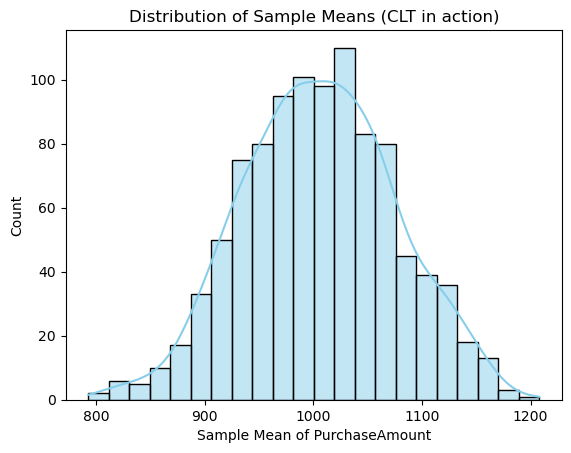

In [45]:
# What insights can we gain by applying the Central Limit Theorem?

sample_means = [df['PurchaseAmount'].dropna().sample(50).mean() for _ in range(1000)]


sns.histplot(sample_means, kde=True, color="skyblue")
plt.title("Distribution of Sample Means (CLT in action)")
plt.xlabel("Sample Mean of PurchaseAmount")
plt.show()

In [46]:
# What is the 95% confidence interval for the average PurchaseAmount?

purchase_data = df['PurchaseAmount'].dropna()

mean_val = purchase_data.mean()
std_err = stats.sem(purchase_data)  

# 95% confidence interval using t-distribution
ci = stats.t.interval(
    0.95,                    
    len(purchase_data) - 1, 
    loc=mean_val,              
    scale=std_err            
)

{
    "Mean PurchaseAmount": mean_val,
    "95% Confidence Interval": ci
}

{'Mean PurchaseAmount': np.float64(1003.9506701030928),
 '95% Confidence Interval': (np.float64(990.3789594609216),
  np.float64(1017.522380745264))}